# Pertemuan 6 - Hands-on: Preprocessing Dataset Titanic

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Mata Kuliah**: Data Science  

## Langkah 1: Load Dataset & EDA Singkat

Pada tahap ini dataset Titanic dimuat dari library Seaborn. Setelah itu hanya kolom yang dibutuhkan yang dipilih, lalu dilakukan pengecekan bentuk data, missing values, tipe data, dan distribusi target `survived`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

# Pilih kolom yang akan digunakan sesuai instruksi modul
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df[cols].copy()

print('Shape:', df.shape)

print('\n5 data teratas:')
display(df.head())

print('\nTipe data:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

print('\nDistribusi target survived:')
print(df['survived'].value_counts(normalize=True).round(3))

Shape: (891, 8)

5 data teratas:


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0



Tipe data:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi target survived:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


### Visualisasi Distribusi Target

Grafik berikut digunakan untuk melihat jumlah penumpang yang selamat dan tidak selamat.

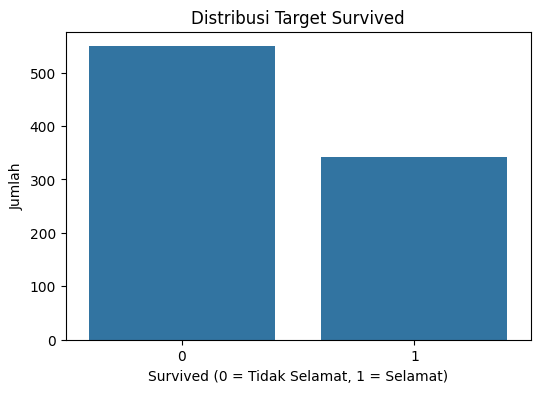

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='survived')
plt.title('Distribusi Target Survived')
plt.xlabel('Survived (0 = Tidak Selamat, 1 = Selamat)')
plt.ylabel('Jumlah')
plt.show()

## Langkah 2: Handling Missing Values

Kolom `age` diisi menggunakan median karena lebih tahan terhadap outlier. Kolom `embarked` diisi menggunakan modus karena merupakan data kategorikal.

In [3]:
# Age: isi dengan median
df['age'] = df['age'].fillna(df['age'].median())

# Embarked: isi dengan modus
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing setelah handling:')
print(df.isnull().sum())

Missing setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


## Langkah 3: Encoding Kategorikal

Kolom kategorikal `sex` dan `embarked` diubah menjadi bentuk numerik menggunakan One-Hot Encoding. Parameter `drop_first=True` digunakan untuk menghindari dummy variable trap.

In [4]:
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,
    dtype=int
)

print('Kolom setelah encoding:')
print(df.columns.tolist())

print('\n5 data teratas setelah encoding:')
display(df.head())

Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']

5 data teratas setelah encoding:


,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,1,0,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,1


## Langkah 4: Train-Test Split

Data dipisahkan menjadi fitur `X` dan target `y`. Kemudian data dibagi menjadi 80% training set dan 20% test set. Parameter `stratify=y` digunakan agar proporsi kelas target tetap terjaga pada data train dan test.

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')

print('\nProporsi survived di Train:')
print(y_train.value_counts(normalize=True).round(3))

print('\nProporsi survived di Test:')
print(y_test.value_counts(normalize=True).round(3))

Train: 712 baris
Test : 179 baris

Proporsi survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## Langkah 5: Feature Scaling

Scaling dilakukan hanya pada kolom numerik, yaitu `pclass`, `age`, `sibsp`, `parch`, dan `fare`. Kolom hasil One-Hot Encoding seperti `sex_male`, `embarked_Q`, dan `embarked_S` tidak perlu di-scale karena sudah berbentuk biner 0/1.

Scaler hanya di-fit pada data training untuk mencegah data leakage. Data test hanya menggunakan `transform()`.

In [6]:
from sklearn.preprocessing import StandardScaler

num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']

scaler = StandardScaler()

# Gunakan .copy() agar tidak muncul SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# fit_transform hanya pada training set
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# transform saja pada test set
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Mean scaler dari train:', scaler.mean_.round(2))
print('Std scaler dari train :', scaler.scale_.round(2))

print('\nContoh X_train setelah scaling:')
display(X_train.head(3).round(3))

print('\nData siap dilatih model Machine Learning!')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')

Mean scaler dari train: [ 2.31 29.46  0.49  0.39 31.82]
Std scaler dari train : [ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train setelah scaling:


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
692,0.830,-0.112,-0.465,-0.466,0.514,1,0,1
481,-0.371,-0.112,-0.465,-0.466,-0.663,1,0,1
527,-1.571,-0.112,-0.465,-0.466,3.955,1,0,1



Data siap dilatih model Machine Learning!
X_train: (712, 8), y_train: (712,)
X_test : (179, 8), y_test : (179,)


## Kesimpulan

Berdasarkan hasil preprocessing, dataset Titanic sudah siap digunakan untuk proses Machine Learning. Missing values pada kolom `age` dan `embarked` telah ditangani, data kategorikal sudah diubah menjadi numerik menggunakan One-Hot Encoding, data sudah dipisahkan menjadi training set dan test set menggunakan stratifikasi, serta fitur numerik sudah di-scale menggunakan StandardScaler tanpa menyebabkan data leakage.